In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Load final dataset
df = pd.read_csv(r'C:\Users\namra\gluten-free-spatial-inequality\data\processed\analytical_dataset_final.csv')

# Select the three variables for Ball Mapper point cloud
variables = ['prescribing_rate_recent', 'retail_accessibility_score', 'imd_score_weighted']
labels = ['Recent prescribing rate', 'Retail accessibility', 'IMD score (weighted)']

X_raw = df[variables].values

# Standardise to z-scores
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print("Point cloud shape:", X_scaled.shape)
print("\nRaw variable ranges:")
for v, l in zip(variables, labels):
    print(f"  {l}: {df[v].min():.3f} – {df[v].max():.3f}")
print("\nScaled variable ranges:")
for i, l in enumerate(labels):
    print(f"  {l}: {X_scaled[:,i].min():.3f} – {X_scaled[:,i].max():.3f}")

Point cloud shape: (106, 3)

Raw variable ranges:
  Recent prescribing rate: 0.000 – 28.161
  Retail accessibility: 0.170 – 0.424
  IMD score (weighted): 10.132 – 43.467

Scaled variable ranges:
  Recent prescribing rate: -0.960 – 2.365
  Retail accessibility: -2.048 – 2.627
  IMD score (weighted): -1.700 – 2.756


In [2]:
def ball_mapper(X, epsilon):
    """
    Ball Mapper algorithm implementation.
    Following Dlotko (2019) and Dlotko, Qiu and Rudkin (2022).
    
    Parameters:
        X: numpy array of shape (n_points, n_dimensions) — standardised point cloud
        epsilon: float — ball radius
    
    Returns:
        nodes: dict — {node_id: list of point indices in that ball}
        edges: list of (node_i, node_j) tuples where balls overlap
    """
    n_points = X.shape[0]
    
    # Compute all pairwise distances
    dist_matrix = euclidean_distances(X)
    
    # Cover point cloud with balls
    covered = np.zeros(n_points, dtype=bool)
    nodes = {}
    node_id = 0
    
    # Iterate through points in order — each uncovered point spawns a new ball
    for i in range(n_points):
        if not covered[i]:
            # Find all points within epsilon of point i
            ball_members = np.where(dist_matrix[i] <= epsilon)[0].tolist()
            nodes[node_id] = ball_members
            # Mark all members as covered
            for j in ball_members:
                covered[j] = True
            node_id += 1
    
    # Find edges — two nodes are connected if their balls share any points
    edges = []
    node_ids = list(nodes.keys())
    for a in range(len(node_ids)):
        for b in range(a + 1, len(node_ids)):
            set_a = set(nodes[node_ids[a]])
            set_b = set(nodes[node_ids[b]])
            if set_a & set_b:  # non-empty intersection
                edges.append((node_ids[a], node_ids[b]))
    
    return nodes, edges


# Epsilon sensitivity analysis
epsilons = [0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0]

print("Epsilon sensitivity analysis:")
print(f"{'Epsilon':>10} {'Nodes':>8} {'Edges':>8} {'Connected':>12} {'Components':>12} {'Avg node size':>15}")
print("-" * 70)

results = []
for eps in epsilons:
    nodes, edges = ball_mapper(X_scaled, eps)
    G = nx.Graph()
    G.add_nodes_from(nodes.keys())
    G.add_edges_from(edges)
    
    n_components = nx.number_connected_components(G)
    is_connected = nx.is_connected(G)
    avg_size = np.mean([len(v) for v in nodes.values()])
    
    results.append({
        'epsilon': eps,
        'n_nodes': len(nodes),
        'n_edges': len(edges),
        'connected': is_connected,
        'n_components': n_components,
        'avg_node_size': avg_size
    })
    
    print(f"{eps:>10.2f} {len(nodes):>8} {len(edges):>8} {str(is_connected):>12} {n_components:>12} {avg_size:>15.1f}")

Epsilon sensitivity analysis:
   Epsilon    Nodes    Edges    Connected   Components   Avg node size
----------------------------------------------------------------------
      0.50       59       18        False           45             2.2
      0.75       38       26        False           19             3.8
      1.00       29       46        False            5             6.4
      1.25       17       24        False            2             9.6
      1.50       12       20        False            2            15.7
      1.75        9       12        False            2            18.3
      2.00        7       11         True            1            25.7
      2.50        6       14         True            1            43.3
      3.00        4        6         True            1            68.8


In [3]:
# Build Ball Mapper at selected epsilon
EPSILON = 2.0
nodes, edges = ball_mapper(X_scaled, EPSILON)

print(f"Ball Mapper at epsilon = {EPSILON}")
print(f"Nodes: {len(nodes)}, Edges: {len(edges)}")
print(f"\nNode composition:")
for nid, members in nodes.items():
    presc = df['prescribing_rate_recent'].iloc[members].mean()
    retail = df['retail_accessibility_score'].iloc[members].mean()
    imd = df['imd_score_weighted'].iloc[members].mean()
    print(f"  Node {nid}: {len(members)} areas | "
          f"prescribing={presc:.1f} | retail={retail:.3f} | IMD={imd:.1f}")

# Compute node properties for colouring
node_prescribing = {nid: df['prescribing_rate_recent'].iloc[members].mean() 
                    for nid, members in nodes.items()}
node_retail = {nid: df['retail_accessibility_score'].iloc[members].mean() 
               for nid, members in nodes.items()}
node_imd = {nid: df['imd_score_weighted'].iloc[members].mean() 
            for nid, members in nodes.items()}
node_size = {nid: len(members) for nid, members in nodes.items()}

# Build networkx graph for layout
G = nx.Graph()
G.add_nodes_from(nodes.keys())
G.add_edges_from(edges)

# Use spring layout for positioning
pos = nx.spring_layout(G, seed=42, k=2)

print(f"\nGraph connected: {nx.is_connected(G)}")
print(f"Graph components: {nx.number_connected_components(G)}")

Ball Mapper at epsilon = 2.0
Nodes: 7, Edges: 11

Node composition:
  Node 0: 44 areas | prescribing=15.2 | retail=0.287 | IMD=23.1
  Node 1: 23 areas | prescribing=3.1 | retail=0.277 | IMD=30.2
  Node 2: 60 areas | prescribing=3.6 | retail=0.285 | IMD=19.2
  Node 3: 5 areas | prescribing=20.6 | retail=0.352 | IMD=33.1
  Node 4: 9 areas | prescribing=3.6 | retail=0.376 | IMD=15.8
  Node 5: 16 areas | prescribing=18.1 | retail=0.239 | IMD=31.6
  Node 6: 23 areas | prescribing=2.6 | retail=0.232 | IMD=19.2

Graph connected: True
Graph components: 1


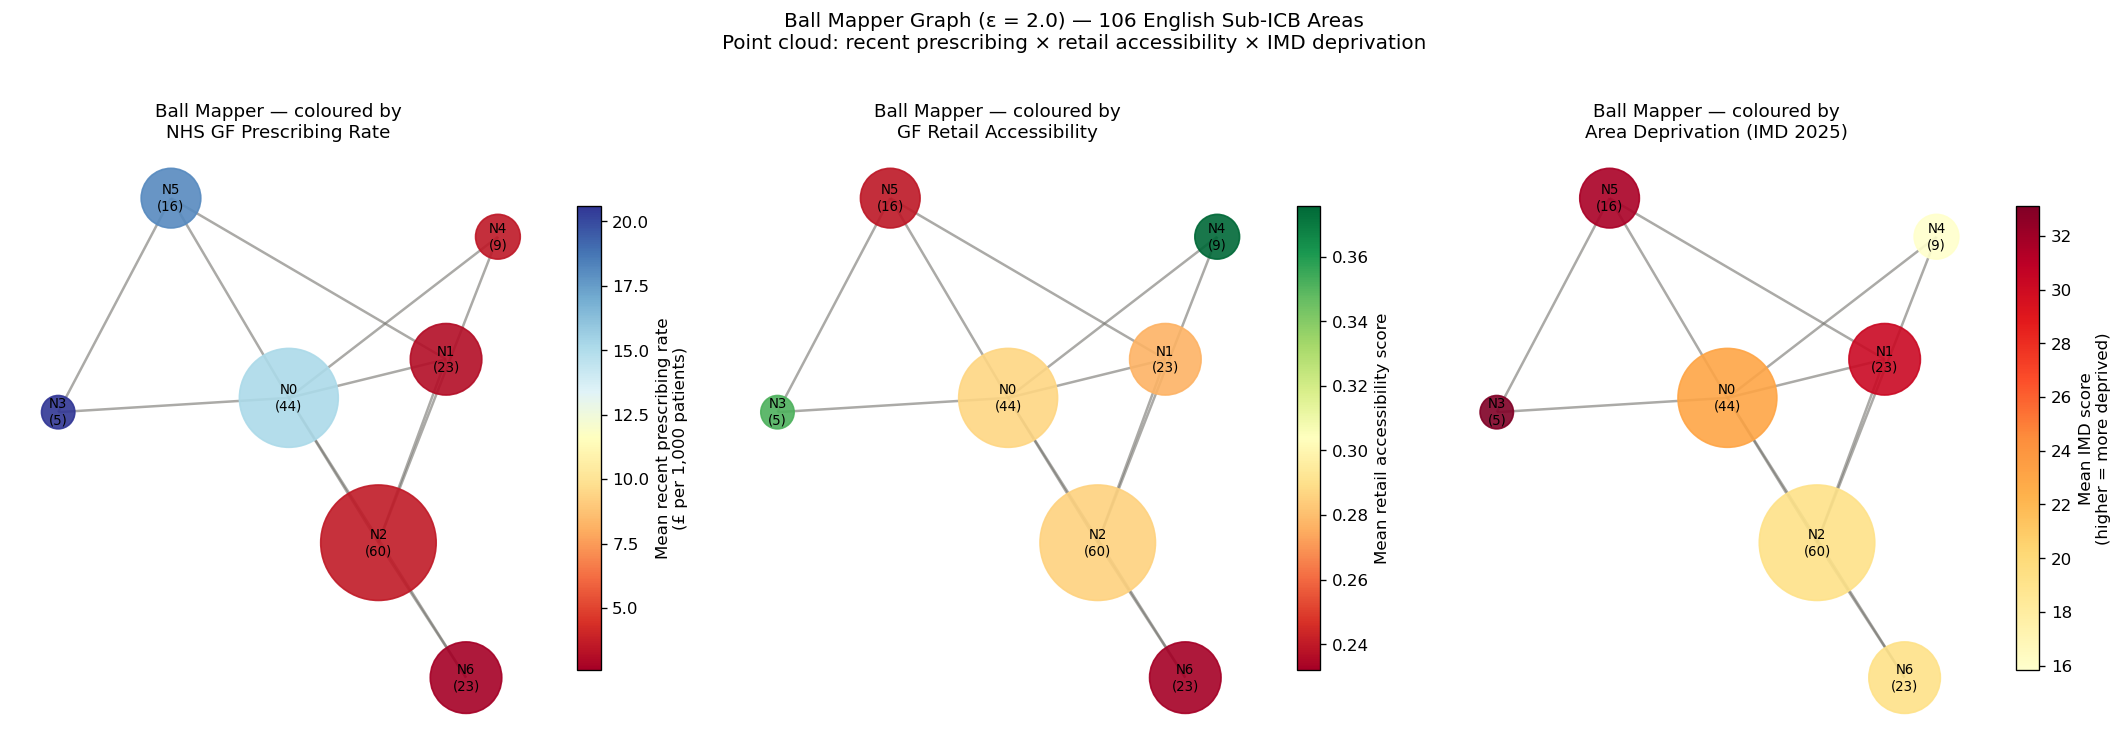

Saved.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Node sizes proportional to number of areas
node_sizes = [node_size[n] * 80 for n in G.nodes()]

# --- Plot 1: Coloured by prescribing rate ---
presc_vals = [node_prescribing[n] for n in G.nodes()]
presc_min, presc_max = min(presc_vals), max(presc_vals)

norm_presc = plt.Normalize(presc_min, presc_max)
cmap_presc = plt.cm.RdYlBu

node_colors_presc = [cmap_presc(norm_presc(v)) for v in presc_vals]

nx.draw_networkx_nodes(G, pos, ax=axes[0], node_size=node_sizes,
                       node_color=node_colors_presc, alpha=0.9)
nx.draw_networkx_edges(G, pos, ax=axes[0], edge_color='#73726c',
                       width=1.5, alpha=0.6)
nx.draw_networkx_labels(G, pos, ax=axes[0],
                        labels={n: f"N{n}\n({node_size[n]})" for n in G.nodes()},
                        font_size=8, font_color='black')

sm1 = plt.cm.ScalarMappable(cmap=cmap_presc, norm=norm_presc)
sm1.set_array([])
plt.colorbar(sm1, ax=axes[0], shrink=0.8, label='Mean recent prescribing rate\n(£ per 1,000 patients)')
axes[0].set_title('Ball Mapper — coloured by\nNHS GF Prescribing Rate', fontsize=11)
axes[0].axis('off')

# --- Plot 2: Coloured by retail accessibility ---
retail_vals = [node_retail[n] for n in G.nodes()]
retail_min, retail_max = min(retail_vals), max(retail_vals)

norm_retail = plt.Normalize(retail_min, retail_max)
cmap_retail = plt.cm.RdYlGn

node_colors_retail = [cmap_retail(norm_retail(v)) for v in retail_vals]

nx.draw_networkx_nodes(G, pos, ax=axes[1], node_size=node_sizes,
                       node_color=node_colors_retail, alpha=0.9)
nx.draw_networkx_edges(G, pos, ax=axes[1], edge_color='#73726c',
                       width=1.5, alpha=0.6)
nx.draw_networkx_labels(G, pos, ax=axes[1],
                        labels={n: f"N{n}\n({node_size[n]})" for n in G.nodes()},
                        font_size=8, font_color='black')

sm2 = plt.cm.ScalarMappable(cmap=cmap_retail, norm=norm_retail)
sm2.set_array([])
plt.colorbar(sm2, ax=axes[1], shrink=0.8, label='Mean retail accessibility score')
axes[1].set_title('Ball Mapper — coloured by\nGF Retail Accessibility', fontsize=11)
axes[1].axis('off')

# --- Plot 3: Coloured by IMD ---
imd_vals = [node_imd[n] for n in G.nodes()]
imd_min, imd_max = min(imd_vals), max(imd_vals)

norm_imd = plt.Normalize(imd_min, imd_max)
cmap_imd = plt.cm.YlOrRd

node_colors_imd = [cmap_imd(norm_imd(v)) for v in imd_vals]

nx.draw_networkx_nodes(G, pos, ax=axes[2], node_size=node_sizes,
                       node_color=node_colors_imd, alpha=0.9)
nx.draw_networkx_edges(G, pos, ax=axes[2], edge_color='#73726c',
                       width=1.5, alpha=0.6)
nx.draw_networkx_labels(G, pos, ax=axes[2],
                        labels={n: f"N{n}\n({node_size[n]})" for n in G.nodes()},
                        font_size=8, font_color='black')

sm3 = plt.cm.ScalarMappable(cmap=cmap_imd, norm=norm_imd)
sm3.set_array([])
plt.colorbar(sm3, ax=axes[2], shrink=0.8, label='Mean IMD score\n(higher = more deprived)')
axes[2].set_title('Ball Mapper — coloured by\nArea Deprivation (IMD 2025)', fontsize=11)
axes[2].axis('off')

plt.suptitle(f'Ball Mapper Graph (ε = {EPSILON}) — 106 English Sub-ICB Areas\n'
             f'Point cloud: recent prescribing × retail accessibility × IMD deprivation',
             fontsize=12, fontweight='500', y=1.02)
plt.tight_layout()

plt.savefig(r'C:\Users\namra\gluten-free-spatial-inequality\outputs\figures\09_ballmapper_coloured.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved.")

In [5]:
# Identify areas in each node
print("BALL MAPPER NODE MEMBERSHIP")
print("="*70)

for nid, members in nodes.items():
    presc = df['prescribing_rate_recent'].iloc[members].mean()
    retail = df['retail_accessibility_score'].iloc[members].mean()
    imd = df['imd_score_weighted'].iloc[members].mean()
    
    print(f"\nNode {nid} ({len(members)} areas) | "
          f"prescribing={presc:.1f} | retail={retail:.3f} | IMD={imd:.1f}")
    print("-"*60)
    
    node_df = df.iloc[members][['org_name', 'prescribing_rate_recent',
                                 'retail_accessibility_score', 
                                 'imd_score_weighted',
                                 'months_zero']].copy()
    node_df = node_df.sort_values('prescribing_rate_recent', ascending=False)
    node_df.columns = ['Area', 'Prescribing', 'Retail', 'IMD', 'Months zero']
    print(node_df.round(2).to_string(index=False))

BALL MAPPER NODE MEMBERSHIP

Node 0 (44 areas) | prescribing=15.2 | retail=0.287 | IMD=23.1
------------------------------------------------------------
                                                   Area  Prescribing  Retail   IMD  Months zero
                           NHS EAST RIDING OF YORKSHIRE        28.16    0.24 16.23            0
                                      NHS BLACK COUNTRY        27.23    0.27 30.21            0
                                       NHS VALE OF YORK        26.04    0.25 12.41            0
                            NHS BIRMINGHAM AND SOLIHULL        25.93    0.31 34.77            0
                                           NHS BARNSLEY        23.47    0.26 30.06            0
                                 NHS NORTH LINCOLNSHIRE        22.68    0.22 23.47            0
                                      NHS WIGAN BOROUGH        22.31    0.23 25.21            0
                                          NHS SHEFFIELD        21.88    0.30 27

BALL MAPPER NODE SUMMARY TABLE
Node                          Label  Areas  Mean prescribing  Mean retail  Mean IMD  Mean months zero Equity concern
  N0         Consistent prescribers     44              15.2        0.287      23.1               0.1         Medium
  N1           Deprived withdrawers     23               3.1        0.277      30.2              10.0           High
  N2    Low-deprivation withdrawers     60               3.6        0.285      19.2               4.4            Low
  N3               Double provision      5              20.6        0.352      33.1               0.0            Low
  N4           Affluent retail-only      9               3.6        0.376      15.8               2.6            Low
  N5         Deprived NHS-dependent     16              18.1        0.239      31.6               0.2           High
  N6 Structural double disadvantage     23               2.6        0.232      19.2               3.4           High


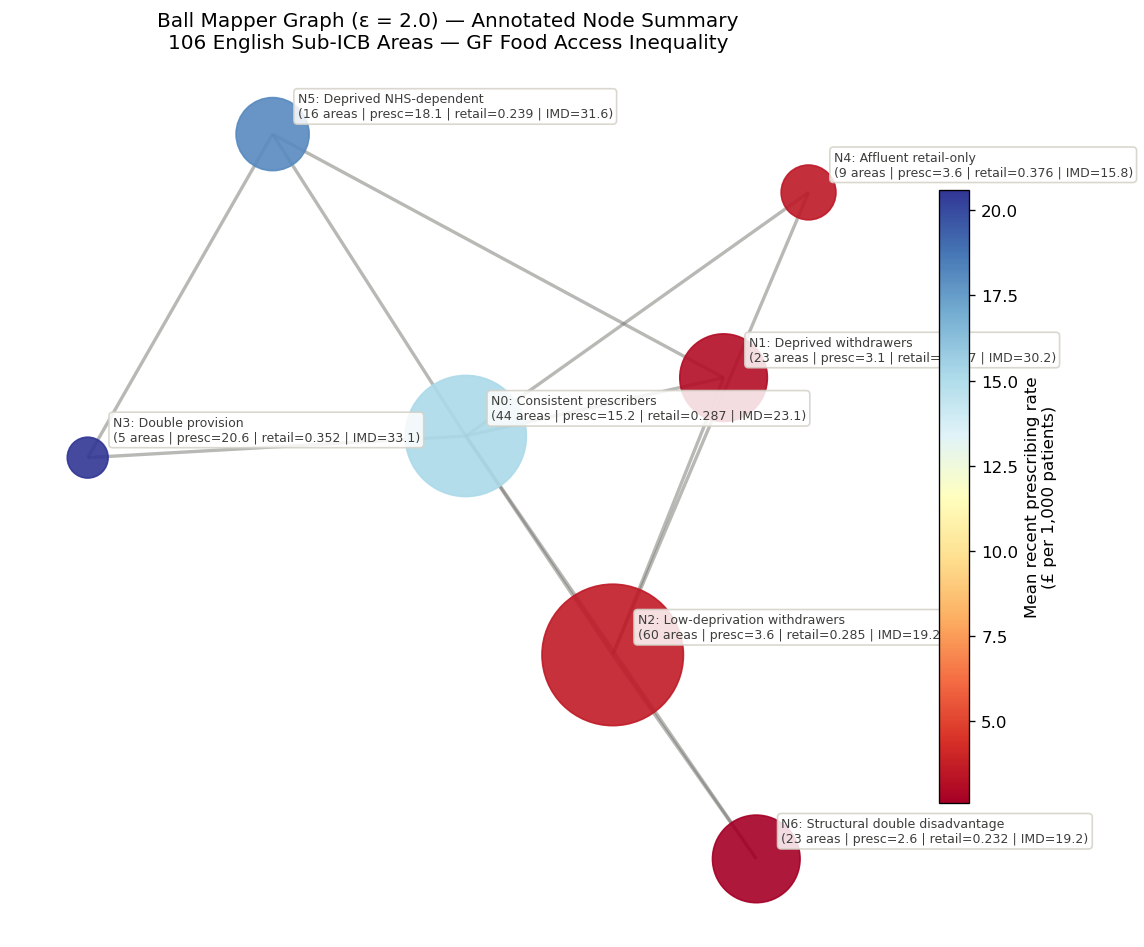

Saved.


In [6]:
# Summary table of node characteristics
summary_data = []
node_labels = {
    0: 'Consistent prescribers',
    1: 'Deprived withdrawers',
    2: 'Low-deprivation withdrawers', 
    3: 'Double provision',
    4: 'Affluent retail-only',
    5: 'Deprived NHS-dependent',
    6: 'Structural double disadvantage'
}

for nid, members in nodes.items():
    summary_data.append({
        'Node': f'N{nid}',
        'Label': node_labels[nid],
        'Areas': len(members),
        'Mean prescribing': round(df['prescribing_rate_recent'].iloc[members].mean(), 1),
        'Mean retail': round(df['retail_accessibility_score'].iloc[members].mean(), 3),
        'Mean IMD': round(df['imd_score_weighted'].iloc[members].mean(), 1),
        'Mean months zero': round(df['months_zero'].iloc[members].mean(), 1),
        'Equity concern': ['Medium', 'High', 'Low', 'Low', 'Low', 'High', 'High'][nid]
    })

summary_df = pd.DataFrame(summary_data)
print("BALL MAPPER NODE SUMMARY TABLE")
print("="*100)
print(summary_df.to_string(index=False))

# Save summary table
summary_df.to_csv(r'C:\Users\namra\gluten-free-spatial-inequality\outputs\tables\ballmapper_node_summary.csv',
                  index=False)

# Final figure - annotated Ball Mapper with node labels
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

presc_vals = [node_prescribing[n] for n in G.nodes()]
norm_presc = plt.Normalize(min(presc_vals), max(presc_vals))
cmap_presc = plt.cm.RdYlBu
node_colors = [cmap_presc(norm_presc(v)) for v in presc_vals]
node_sizes = [node_size[n] * 120 for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes,
                       node_color=node_colors, alpha=0.9)
nx.draw_networkx_edges(G, pos, ax=ax, edge_color='#73726c',
                       width=2, alpha=0.5)

for n in G.nodes():
    x, y = pos[n]
    ax.annotate(f"N{n}: {node_labels[n]}\n"
                f"({node_size[n]} areas | presc={node_prescribing[n]:.1f} | "
                f"retail={node_retail[n]:.3f} | IMD={node_imd[n]:.1f})",
                xy=(x, y), xytext=(15, 10), textcoords='offset points',
                fontsize=7.5, color='#3d3d3a',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor='#d3d1c7', alpha=0.85))

sm = plt.cm.ScalarMappable(cmap=cmap_presc, norm=norm_presc)
sm.set_array([])
plt.colorbar(sm, ax=ax, shrink=0.7, label='Mean recent prescribing rate\n(£ per 1,000 patients)')

ax.set_title(f'Ball Mapper Graph (ε = {EPSILON}) — Annotated Node Summary\n'
             f'106 English Sub-ICB Areas — GF Food Access Inequality',
             fontsize=12, fontweight='500')
ax.axis('off')
plt.tight_layout()

plt.savefig(r'C:\Users\namra\gluten-free-spatial-inequality\outputs\figures\10_ballmapper_annotated.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved.")